In [1]:
import json
import pathlib
from pprint import pprint

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import squareform

import bonsai_loop as bl

sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]
sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]

/home/stan/Git/bonsai-loop/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from bonsai_loop.bonsai_lib import (
    get_pdists_on_tree_euclidean,
)

In [3]:
import inspect

from bonsai_loop.bonsai_lib.bonsai.bonsai_dataprocessing import (  # type: ignore[import]
    loadReconstructedTreeAndData,
)
from bonsai_loop.bonsai_lib.bonsai.bonsai_helpers import (  # type: ignore[import]
    Run_Configs,
)

print(inspect.getsource(loadReconstructedTreeAndData))
print(f"{'─' * 88}")
pprint(Run_Configs.__dict__)

def loadReconstructedTreeAndData(args, tree_folder, reprocess_data=False, all_genes=False, all_ranks=True,
                                 get_cell_info=False, corrected_data=True, rel_to_results=False, no_data_needed=False,
                                 single_process=False, keep_original_data=False, calc_loglik=False, get_data=True,
                                 get_posterior_ltqs=False, otherRanksMinimalInfo=False, verbose=True,
                                 calc_posteriors=True):
    """

    :param args:
    :param tree_folder:
    :param reprocess_data:
    :param all_genes:
    :param all_ranks:
    :param get_cell_info:
    :param corrected_data:
    :param rel_to_results:
    :param no_data_needed:
    :param single_process:
    :param keep_original_data:
    :param calc_loglik:
    :param get_data:
    :param get_posterior_ltqs:
    :param otherRanksMinimalInfo:
    :param verbose:
    :param calc_posteriors: This boolean may be false, even when get_posterior_ltqs i

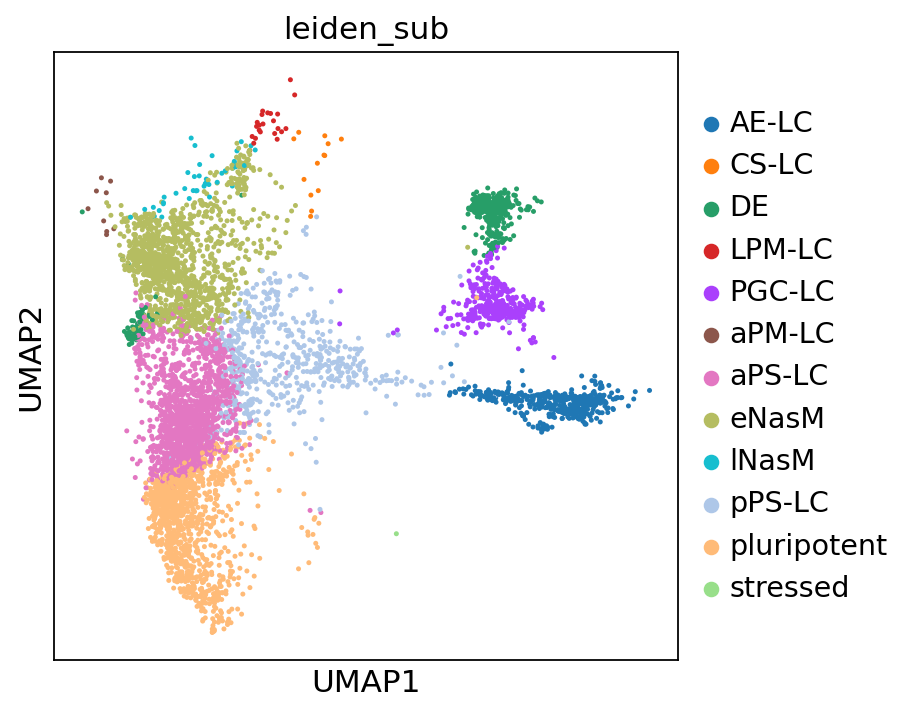

41402

In [4]:
import gc

data_path = pathlib.Path("./data")
adata = sc.read_h5ad(data_path / "adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv(data_path / "adata_timeseries_old_48h-1_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index]
adata.obsm["X_umap"] = np.array(
    adata.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)
sc.pl.umap(adata, color=["leiden_sub"])
del meta
bonsai_gastruloid_path = data_path / "Bonsai_48h-1"
gas_bonsai_output_folder = bonsai_gastruloid_path / "final_bonsai_zscore0.75/"
gas_bonsai_config_file = bonsai_gastruloid_path / "used_run_configs.yaml"
gc.collect()

05-27 09:32:26 mp_print INFO 

Reconstructed tree loaded from: 
data/Bonsai_48h-1/final_bonsai_zscore0.75/edgeInfo.txt 
data/Bonsai_48h-1/final_bonsai_zscore0.75/vertInfo.txt
05-27 09:32:26 mp_print INFO 
Init min-dist clustering-tree
05-27 09:32:26 mp_print INFO Clustering has created 2 subtrees, 8 branches still to cut.
05-27 09:32:26 mp_print INFO Clustering has created 4 subtrees, 6 branches still to cut.
05-27 09:32:26 mp_print INFO Clustering has created 8 subtrees, 2 branches still to cut.


Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

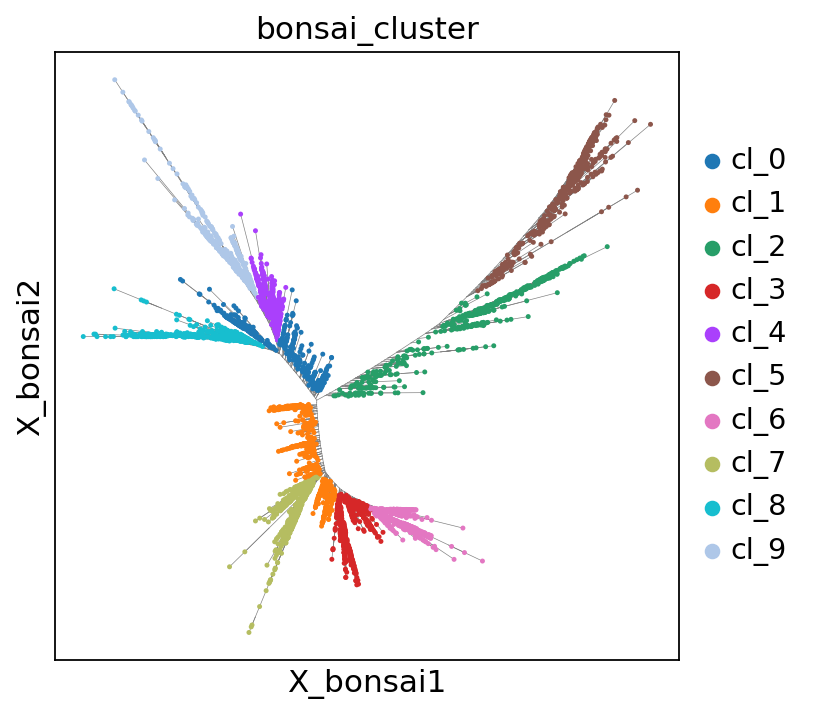

In [5]:
from bonsai_loop.bonsai_lib import bonsai_clustering  # type: ignore[import]

gas_run_configs = Run_Configs(gas_bonsai_config_file)
scData, vert_map = loadReconstructedTreeAndData(
    gas_run_configs,
    gas_bonsai_output_folder,
    rel_to_results=False,
    reprocess_data=False,
    all_ranks=False,
    get_cell_info=True,
    get_posterior_ltqs=True,
)
# compute dsLeafs for dendrogram
scData.tree.root.get_ds_info_for_ladderize()
# reroot
gas_node_id_to_vert_ind = {}
with open(gas_bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        gas_node_id_to_vert_ind[parts[2]] = int(parts[0])
new_root = "internal_1880"
scData.tree.reset_root(gas_node_id_to_vert_ind[new_root])
# clustering
f = h5py.File(bonsai_gastruloid_path / "bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]  # type: ignore[index]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]  # type: ignore[index]
cell_inds = f["tree_info/cell_inds"][:]  # type: ignore[index]
int_inds = f["tree_info/int_inds"][:]  # type: ignore[index]
metadata = json.loads(f.attrs["metadata_json"])  # type: ignore[index]
gas_cell_ids = metadata["cellIds"]  # type: ignore[index]
gas_vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])  # type: ignore[index]

cell_coords = np.zeros((len(gas_cell_ids), 2))
for vert_idx_str, cell_idx in gas_vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]  # type: ignore[index]
    else:
        cell_coords[cell_idx] = coords[vert_idx]  # type: ignore[index]
adata.obsm["X_bonsai"] = cell_coords
f.close()

with open(gas_bonsai_output_folder / "tree.nwk") as f:
    nwk_str = f.read().strip()
all_clusters, _ = bonsai_clustering.get_min_pdists_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, n_clusters=10
)
gas_clusters = all_clusters[f"annot_bnsi_cluster_n{10}"]
cluster_dict = bonsai_clustering.get_cluster_assignments({"annot": gas_clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

if "bonsai_cluster_colors" in adata.uns:
    del adata.uns["bonsai_cluster_colors"]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

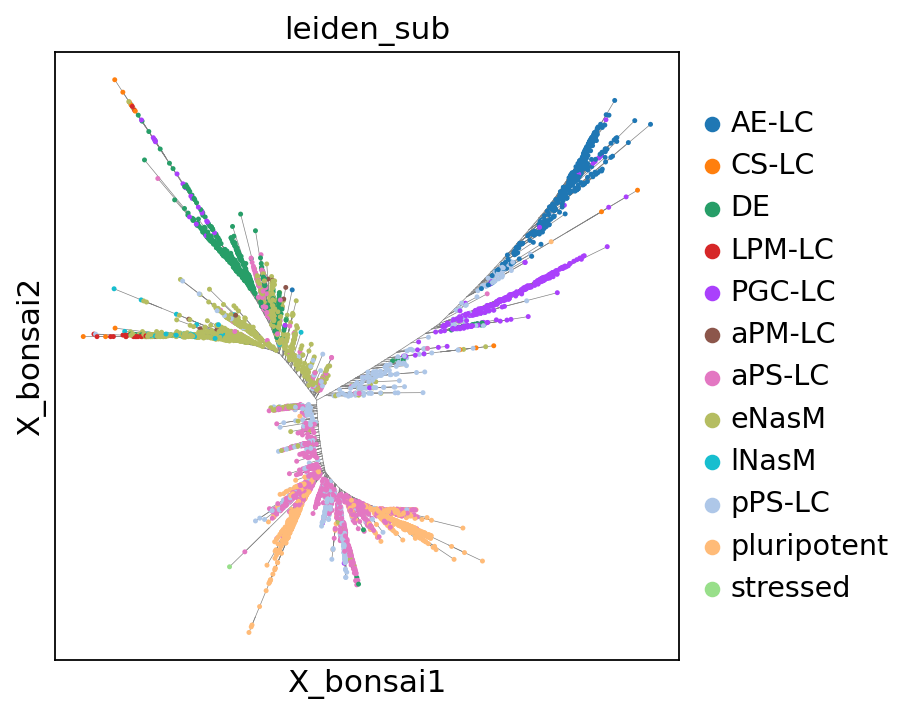

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)

# Test deviation score accumulation

In [7]:
node_data_lookup = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["bonsai_cluster"].to_dict(),
)
bl.convergence.compute_bonsai_tree_dendrogram(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
    ladderize_by_annotated_leaves_only=True,
)

compute depth-first ordering of nodes
root node internal_1880
compute node level and label


11069it [00:00, 283157.28it/s]


In [8]:
# root node should have n_leaves = number of real cells (n=5927)
print(node_data_lookup["internal_1880"])
# a real cell (a leaf) should have n_leaves = 1
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌─────────────────────────────┬──────────────────────────────────────────────┐
│ attribute                   │ value                                        │
├─────────────────────────────┼──────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='internal_1880')             │
│ topological_level           │ 195                                          │
│ geometric_level             │ None                                         │
│ identity                    │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves                    │ 5927                                         │
│ ordering_value              │ None                                         │
│ dendrogram_coords           │ (-0.95, -0.9159482420614774)                 │
│ delta_deviation_from_parent │ None                                         │
│ other_props                 │ None                                         │
└─────────────────────────────┴─────────────────────

In [9]:
# compute ordering
bl.convergence.compute_node_ordering_value(
    tree=scData.tree, node_data_lookup=node_data_lookup, metric="dendrogram"
)
ordering_node_ids = bl.convergence.compute_node_ordering(
    node_data_lookup=node_data_lookup,
    level=0,
    sort_by_identity_first=False,
    ascending=True,
)
# compute delta deviation scores for all nodes
# here we set normalize_by_branch_length=False in order to test deviation score accumulation
bl.convergence.compute_delta_deviation_from_parent(
    node_data_lookup=node_data_lookup,
    reference_node_ids=ordering_node_ids,
    normalize_by_branch_length=False,
)

compute node ordering using metric dendrogram
compute deviations for 11068 branches × 5927 refs


In [10]:
# root node (root has no parent so no deviation score)
print(node_data_lookup["internal_1880"])
print(f"{'─' * 88}")
# a internal node
print(node_data_lookup["internal_720"])
# query some deviation scores for different reference nodes
print(node_data_lookup["internal_720"].delta_deviation_from_parent[0])
print(node_data_lookup["internal_720"].delta_deviation_from_parent[1])
print(f"{'─' * 88}")
# a real cell (a leaf)
print(node_data_lookup["AAACGAATCTGCAGCG-1_48h"])
# query some deviation scores
# can query by index
print(node_data_lookup["AAACGAATCTGCAGCG-1_48h"].delta_deviation_from_parent[50])
# or by node id
print(
    node_data_lookup["AAACGAATCTGCAGCG-1_48h"].delta_deviation_from_parent[
        "TTTGGTTTCACAACCA-1_48h"
    ]
)

┌─────────────────────────────┬──────────────────────────────────────────────┐
│ attribute                   │ value                                        │
├─────────────────────────────┼──────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='internal_1880')             │
│ topological_level           │ 195                                          │
│ geometric_level             │ None                                         │
│ identity                    │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves                    │ 5927                                         │
│ ordering_value              │ -0.9159482420614774                          │
│ dendrogram_coords           │ (-0.95, -0.9159482420614774)                 │
│ delta_deviation_from_parent │ None                                         │
│ other_props                 │ None                                         │
└─────────────────────────────┴─────────────────────

In [11]:
# test no move
leaf_node_id = "AAACGAATCTGCAGCG-1_48h"
# an arbitrary reference leaf node
reference_node_id = "AAACCCAAGGACTAAT-1_48h"
acc_score, end_node_id = bl.convergence.accumulate_delta_deviation_scores_along_lineage(
    node_data_lookup=node_data_lookup,
    source_node_id=leaf_node_id,
    reference_node_id=reference_node_id,
    n_steps=0,
    direction="up",
    target_node_id=None,
)
# should be the same node as n_steps=0 and accumulated score (acc_score) should be 0
print(f"end_node_id: {end_node_id}")
print(f"acc_score: {acc_score}")

end_node_id: AAACGAATCTGCAGCG-1_48h
acc_score: 0.0


In [12]:
# test move one step up
acc_score, end_node_id = bl.convergence.accumulate_delta_deviation_scores_along_lineage(
    node_data_lookup=node_data_lookup,
    source_node_id=leaf_node_id,
    reference_node_id=reference_node_id,
    n_steps=1,
    direction="up",
    target_node_id=None,
)
# should be the direct parent of the source node as n_steps=1
# accumulated score (acc_score) should be the same as one step delta deviation (but opposite sign as we walk up)
print(f"end_node_id: {end_node_id}")
print(f"acc_score: {acc_score}")
print(
    f"delta deviation: {node_data_lookup[leaf_node_id].delta_deviation_from_parent[reference_node_id]}"
)

end_node_id: internal_2820
acc_score: 0.0001487001622304876
delta deviation: -0.0001487001622304876


In [13]:
# test one step down
# here we reuse previous end_node_id as the source node and see if we can walk back to the same leaf node
acc_score, end_node_id = bl.convergence.accumulate_delta_deviation_scores_along_lineage(
    node_data_lookup=node_data_lookup,
    source_node_id=end_node_id,
    reference_node_id=reference_node_id,
    target_node_id=leaf_node_id,
)
# should be the same leaf node as the target node
print(f"end_node_id: {end_node_id}")
# accumulated score (acc_score) should be the same as one step delta deviation
# the sign should be the same now as we walk down
print(f"acc_score: {acc_score}")

end_node_id: AAACGAATCTGCAGCG-1_48h
acc_score: -0.0001487001622304876


In [14]:
# now test walk up multiple steps and recover the deviation score
# first move up to get accumulated delta deviation score
n_steps = 5
acc_score, end_node_id = bl.convergence.accumulate_delta_deviation_scores_along_lineage(
    node_data_lookup=node_data_lookup,
    source_node_id=leaf_node_id,
    reference_node_id=reference_node_id,
    n_steps=n_steps,
    direction="up",
)
print(f"start at {leaf_node_id}")
print(f"move up {n_steps} steps to {end_node_id}")
print(f"accumulated delta deviationscore: {acc_score}")

start at AAACGAATCTGCAGCG-1_48h
move up 5 steps to internal_2808
accumulated delta deviationscore: 0.15929438951756286


In [15]:
node_data_lookup[end_node_id]

┌─────────────────────────────┬────────────────────────────────────────────┐
│ attribute                   │ value                                      │
├─────────────────────────────┼────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='internal_2808')           │
│ topological_level           │ 37                                         │
│ geometric_level             │ None                                       │
│ identity                    │ [(cl_2,1.0)]                               │
│ n_leaves                    │ 232                                        │
│ ordering_value              │ 0.08627843183560224                        │
│ dendrogram_coords           │ (0.02035481761580804, 0.08627843183560224) │
│ delta_deviation_from_parent │ dict(n=5927)                               │
│ other_props                 │ None                                       │
└─────────────────────────────┴────────────────────────────────────────────┘

In [16]:
# now we compute deviation score for leaf and end node
# first compute straight line distance matrix
# for leaf node
ndims = node_data_lookup[leaf_node_id].tree_node.ltqsAIRoot.shape[0]
straight_dist_leaf = (
    np.sum(
        (
            node_data_lookup[leaf_node_id].tree_node.ltqsAIRoot
            - node_data_lookup[reference_node_id].tree_node.ltqsAIRoot
        )
        ** 2
    )
    / ndims
)
# for end node
straight_dist_end = (
    np.sum(
        (
            node_data_lookup[end_node_id].tree_node.ltqsAIRoot
            - node_data_lookup[reference_node_id].tree_node.ltqsAIRoot
        )
        ** 2
    )
    / ndims
)

In [17]:
# now compute tree distance matrix (also include the end node)
gas_euclidean_distances_tree = squareform(
    get_pdists_on_tree_euclidean(
        nwk_file=gas_bonsai_output_folder / "tree.nwk",
        bonsai_output_folder=gas_bonsai_output_folder,
        cell_ids=gas_cell_ids + [end_node_id],
    )
)

Done preparing inputs. Starting shortest-path algorithm from Scipy.


In [18]:
# now compute tree distance for leaf and end node
tree_dist_leaf = gas_euclidean_distances_tree[
    np.array(gas_cell_ids + [end_node_id]) == leaf_node_id,
    np.array(gas_cell_ids + [end_node_id]) == reference_node_id,
][0]
tree_dist_end = gas_euclidean_distances_tree[
    np.array(gas_cell_ids + [end_node_id]) == end_node_id,
    np.array(gas_cell_ids + [end_node_id]) == reference_node_id,
][0]
# now compute deviation score
deviation_score_leaf = tree_dist_leaf - straight_dist_leaf
deviation_score_end = tree_dist_end - straight_dist_end

In [19]:
# now verify
print(f"start at {leaf_node_id}")
print(node_data_lookup[leaf_node_id])
print(f"leaf node deviation score: {deviation_score_leaf}")
print(f"move up {n_steps} steps to {end_node_id}")
print(node_data_lookup[end_node_id])
print(f"end node deviation score: {deviation_score_end}")
# should match (small negligible difference due to numerical issues)
print(f"accumulated delta deviation score: {acc_score}")
print(
    f"actual difference in deviation score: {deviation_score_end - deviation_score_leaf}"
)

start at AAACGAATCTGCAGCG-1_48h
┌─────────────────────────────┬────────────────────────────────────────────┐
│ attribute                   │ value                                      │
├─────────────────────────────┼────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='AAACGAATCTGCAGCG-1_48h')  │
│ topological_level           │ 0                                          │
│ geometric_level             │ None                                       │
│ identity                    │ [(cl_2,1.0)]                               │
│ n_leaves                    │ 1                                          │
│ ordering_value              │ 0.09009449881876486                        │
│ dendrogram_coords           │ (0.09773739395356817, 0.09009449881876486) │
│ delta_deviation_from_parent │ dict(n=5927)                               │
│ other_props                 │ None                                       │
└─────────────────────────────┴─────────────

# Deviation score towards DE

In [ ]:
gas_euclidean_distances_tree = squareform(
    get_pdists_on_tree_euclidean(
        nwk_file=gas_bonsai_output_folder / "tree.nwk",
        bonsai_output_folder=gas_bonsai_output_folder,
        cell_ids=gas_cell_ids,
    )
)

In [43]:
# pick a DE reference
from tqdm import tqdm

# here i picked a random one based on bonsai cluster
reference_node_id = adata.obs[adata.obs["bonsai_cluster"] == "cl_9"].index[10]
deviation_loop_up = {}
for leaf_node_id in tqdm(adata.obs.index):
    n_steps = 1
    straight_dist_leaf = (
        np.sum(
            (
                node_data_lookup[leaf_node_id].tree_node.ltqsAIRoot
                - node_data_lookup[reference_node_id].tree_node.ltqsAIRoot
            )
            ** 2
        )
        / ndims
    )
    tree_dist_leaf = gas_euclidean_distances_tree[
        np.array(gas_cell_ids) == leaf_node_id,
        np.array(gas_cell_ids) == reference_node_id,
    ][0]
    deviation_score_leaf = tree_dist_leaf - straight_dist_leaf
    deviation_loop_up[leaf_node_id] = deviation_score_leaf
    while True:
        try:
            acc_score, end_node_id = (
                bl.convergence.accumulate_delta_deviation_scores_along_lineage(
                    node_data_lookup=node_data_lookup,
                    source_node_id=leaf_node_id,
                    reference_node_id=reference_node_id,
                    n_steps=n_steps,
                    direction="up",
                )
            )
            deviation_loop_up[end_node_id] = acc_score + deviation_score_leaf
        except Exception as e:
            break
        n_steps += 1

100%|██████████| 5927/5927 [00:19<00:00, 302.64it/s]


In [57]:
node_data_lookup[child_id].tree_node.nodeId

'internal_1880'

In [63]:
# plot dendrogram
xy = {nid: node_data_lookup[nid].dendrogram_coords for nid in node_data_lookup}
segs, edge_vals = [], []
for child_id in deviation_loop_up.keys():
    parent = node_data_lookup[child_id].tree_node.parentNode
    if parent is None:
        continue
    parent_id = parent.nodeId
    px, py = xy[parent_id]
    cx, cy = xy[child_id]
    segs.append([(px, py), (px, cy), (cx, cy)])
    edge_vals.append(
        node_data_lookup[child_id].delta_deviation_from_parent[reference_node_id]
    )
edge_vals = np.array(edge_vals)
deviation_xy = [deviation_loop_up[nid] for nid in xy.keys()]
xy = np.array(list(xy.values()))
xy_reference = node_data_lookup[reference_node_id].dendrogram_coords

In [92]:
gas_cell_types = pd.Categorical(adata.obs["leiden_sub"]).categories
gas_colors = adata.uns["leiden_sub_colors"]
color_pal = dict(zip(gas_cell_types, gas_colors))
cell_ids = [nid for nid, nd in node_data_lookup.items() if nd.tree_node.isLeaf]
cell_xy = np.array([node_data_lookup[cid].dendrogram_coords for cid in cell_ids])
cell_colors = [color_pal[adata.obs.loc[cid, "leiden_sub"]] for cid in cell_ids]

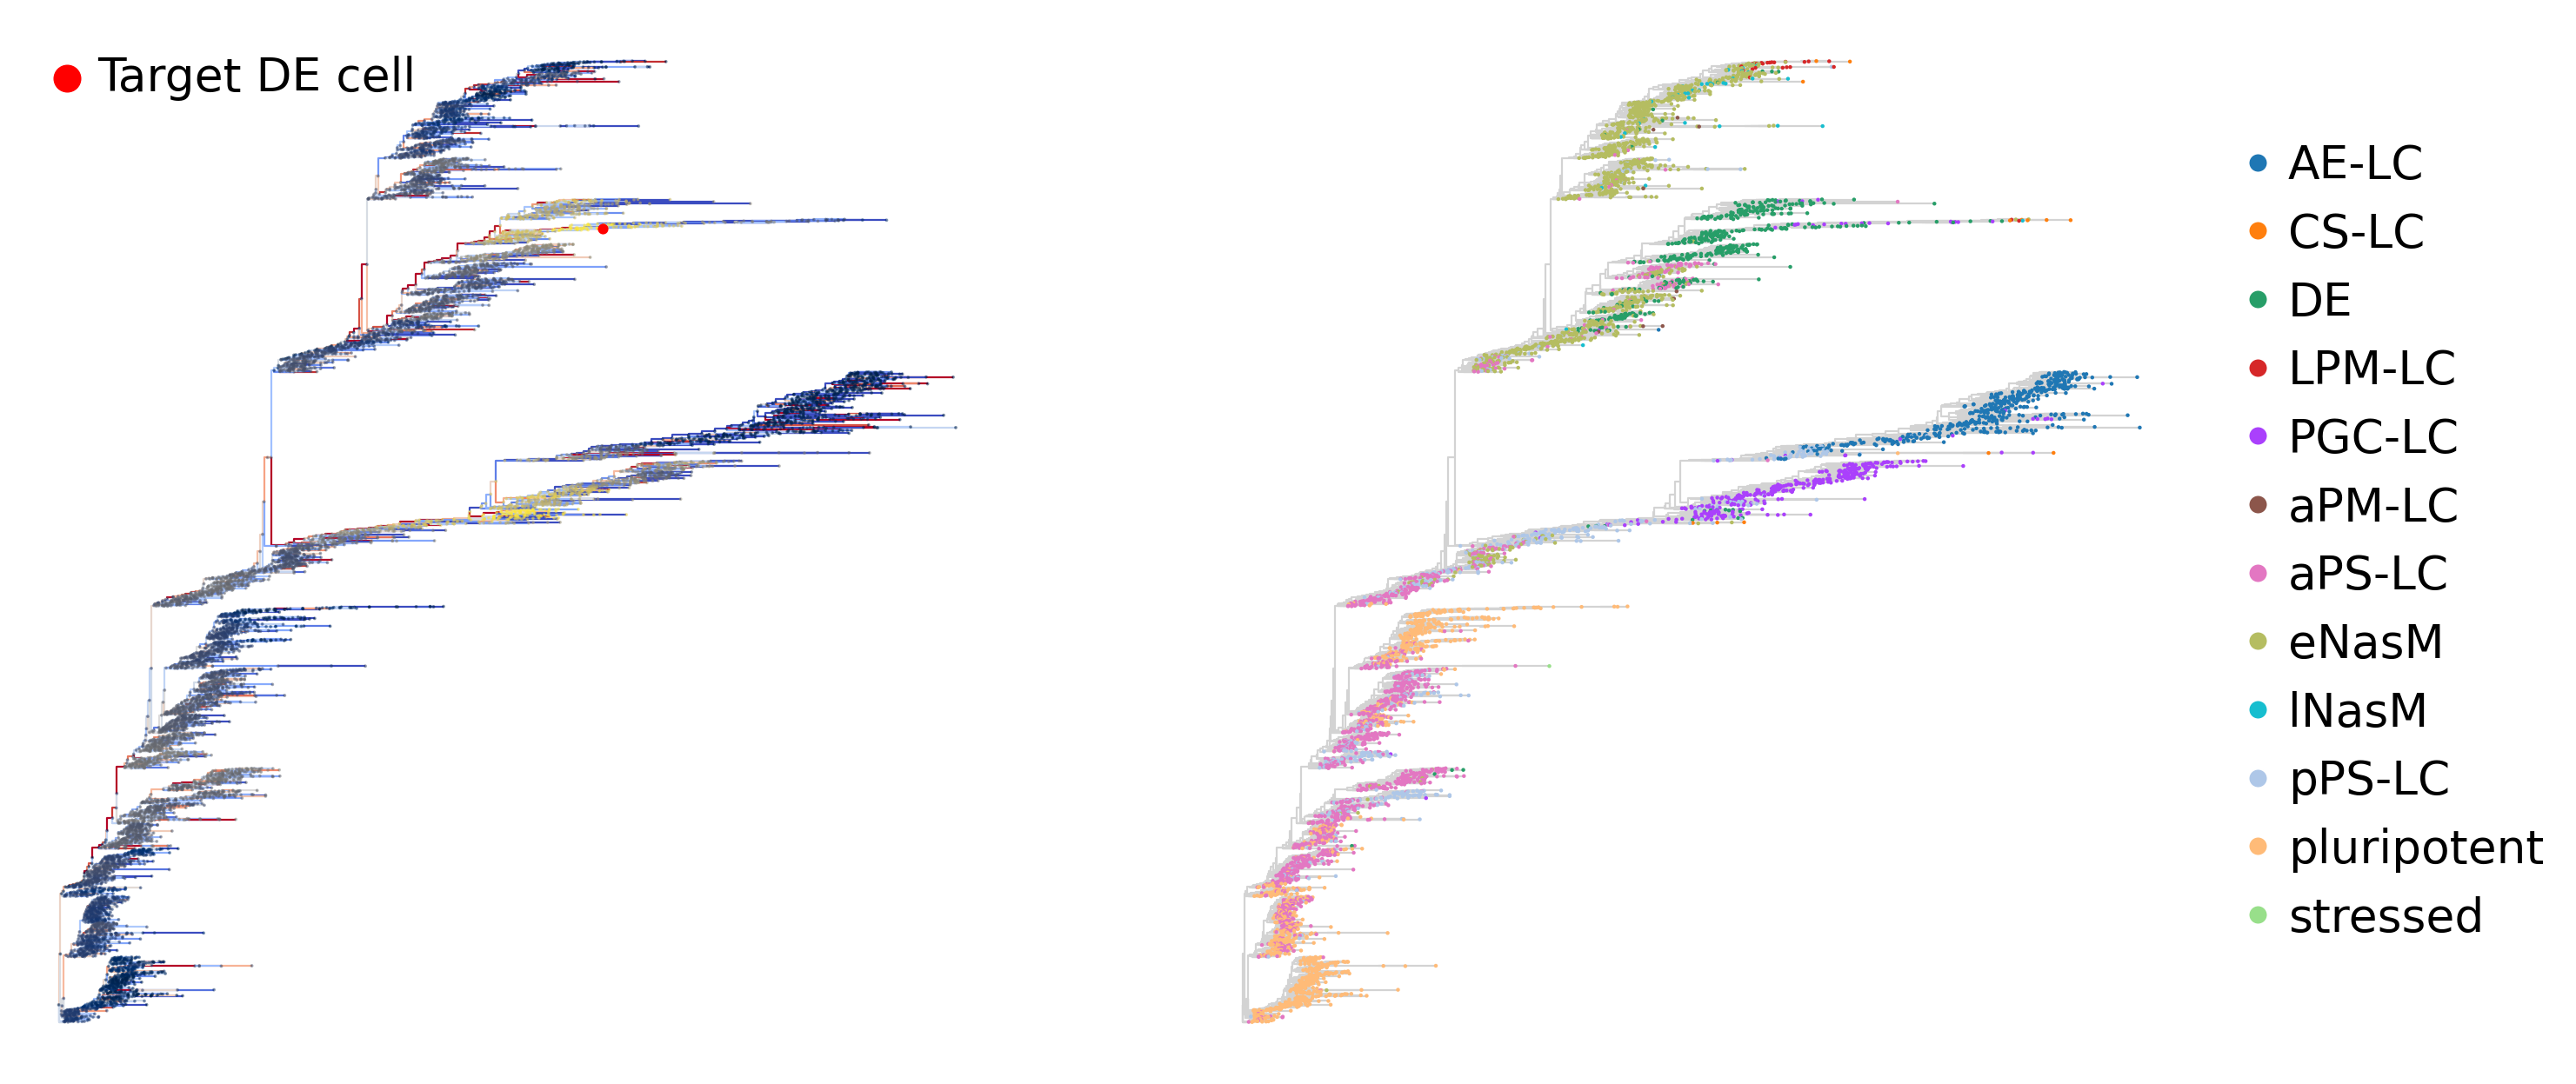

In [116]:
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
ax = axes[0]
elim = np.percentile(np.abs(edge_vals), 95)
lc = LineCollection(
    segs,
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-elim, vcenter=0.0, vmax=elim * 0.75),
    linewidths=1,
    zorder=1,
)
lc.set_array(edge_vals)
ax.add_collection(lc)
cmin, cmax = np.percentile(deviation_xy, [10, 99])
ax.scatter(
    xy[:, 0],
    xy[:, 1],
    c=deviation_xy,
    cmap="cividis",
    vmin=cmin,
    vmax=cmax,
    s=0.5,
    zorder=2,
    alpha=0.5,
)
ax.scatter(
    xy_reference[0], xy_reference[1], c="red", s=20, zorder=3, label="Target DE cell"
)
ax.legend(loc="upper left", frameon=False, fontsize=24, markerscale=3)
ax.grid(False)
ax.set_axis_off()
ax = axes[1]
lc = LineCollection(
    segs,
    linewidths=1,
    zorder=1,
)
lc.set_color("lightgray")
ax.add_collection(lc)

ax.scatter(
    cell_xy[:, 0],
    cell_xy[:, 1],
    c=cell_colors,
    s=4,
    lw=0,
    zorder=2,
)
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color_pal[ct],
        markersize=10,
        linestyle="",
        label=ct,
    )
    for ct in gas_cell_types
]
ax.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=24,
)
ax.grid(False)
ax.set_axis_off()
plt.savefig(
    "figures/deviation_score/dendrogram_deviation_score_DE_cell.png",
    dpi=300,
    bbox_inches="tight",
)